In [1]:
import json, math, os, time
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import clear_output

RESULTS_FILE = '../results.json'
DATASETS     = ['1k', '2k', '5k', '10k']
INTERVAL     = 15  # секунд между обновлениями
TRAIN_CFG_VAL_EVERY = 5
TRAIN_CFG_N_EPOCHS  = 50

In [2]:
def load_results():
    if not os.path.exists(RESULTS_FILE):
        return None
    try:
        with open(RESULTS_FILE, encoding='utf-8') as f:
            return json.load(f)
    except (json.JSONDecodeError, OSError):
        return None


def print_table(results):
    print(f"{'dataset':>8}  {'epochs':>6}  {'loss':>8}  {'SR':>7}  {'mean_len':>9}")
    print('-' * 46)
    for key in DATASETS:
        if key not in results:
            print(f"  {key:>6}  {'—':>6}  {'—':>8}  {'—':>7}  {'—':>9}")
            continue
        h    = results[key]
        ep   = len(h['train_loss'])
        loss = h['train_loss'][-1] if h['train_loss'] else float('nan')
        sr   = h['success_rate'][-1] if h['success_rate'] else float('nan')
        ml   = h['mean_length'][-1]  if h['mean_length']  else float('nan')
        sr_s = f"{sr:.1%}" if not math.isnan(sr) else "—"
        ml_s = f"{ml:.0f}" if not math.isnan(ml) else "—"
        done = '✓' if ep == TRAIN_CFG_N_EPOCHS else f'{ep}/{TRAIN_CFG_N_EPOCHS}'
        print(f"  {key:>6}  {done:>6}  {loss:>8.4f}  {sr_s:>7}  {ml_s:>9}")


def plot_results(results):
    colors = ['C0', 'C1', 'C2', 'C3']
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

    for (key, hist), color in zip(results.items(), colors):
        ep = len(hist['train_loss'])
        if ep == 0:
            continue
        axes[0].plot(range(1, ep + 1), hist['train_loss'], label=key, color=color)

        val_ep = list(range(TRAIN_CFG_VAL_EVERY, ep + 1, TRAIN_CFG_VAL_EVERY))
        n = min(len(val_ep), len(hist['success_rate']))
        if n:
            axes[1].plot(val_ep[:n], hist['success_rate'][:n], marker='o', label=key, color=color)
            axes[2].plot(val_ep[:n], hist['mean_length'][:n],  marker='o', label=key, color=color)

    axes[0].set(title='Train loss',            xlabel='epoch', ylabel='MSE')
    axes[1].set(title='Success rate (rollout)', xlabel='epoch', ylabel='rate')
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes[2].set(title='Mean trajectory length', xlabel='epoch', ylabel='steps')
    for ax in axes:
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

[23:07:32]
 dataset  epochs      loss       SR   mean_len
----------------------------------------------
      1k       ✓    0.0343   100.0%        253
      2k       ✓    0.0221   100.0%        204
      5k       ✓    0.0151   100.0%        449
     10k       ✓    0.0124   100.0%        272


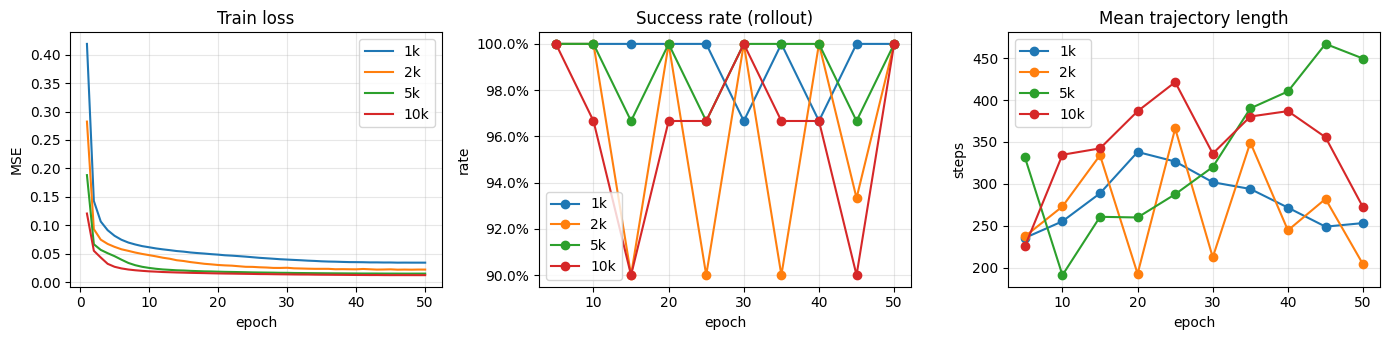

KeyboardInterrupt: 

In [3]:
# Запусти эту ячейку — будет обновляться каждые INTERVAL секунд.
# Прервать: Kernel → Interrupt

while True:
    results = load_results()
    clear_output(wait=True)

    ts = time.strftime('%H:%M:%S')
    if results is None:
        print(f'[{ts}]  Waiting for {RESULTS_FILE}...')
    else:
        print(f'[{ts}]')
        print_table(results)
        plot_results(results)

    time.sleep(INTERVAL)